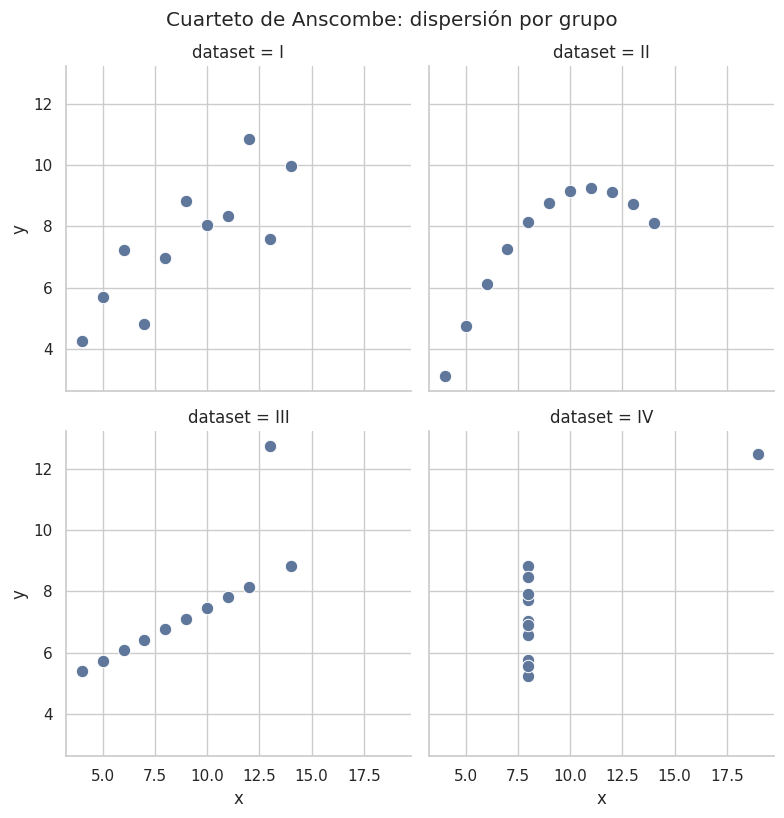

In [46]:
# Parte 0: Importar librerías y cargar el cuarteto de Anscombe
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")
data.head()

# Parte 1: Scatter plot de los 4 grupos del cuarteto de Anscombe
sns.relplot(
    data=data, x='x', y='y', col='dataset', col_wrap=2,
    kind='scatter', s=80, height=4
)
plt.suptitle('Cuarteto de Anscombe: dispersión por grupo', y=1.02)
plt.show()

In [47]:
# Parte 2: Resumen estadístico por grupo con describe()
resumen_por_grupo = data.groupby('dataset').describe()
print(resumen_por_grupo)

# Comparación más legible: solo media y desviación estándar de x e y
comparacion_resumida = data.groupby('dataset').agg(
    x_mean=('x', 'mean'), x_std=('x', 'std'),
    y_mean=('y', 'mean'), y_std=('y', 'std')
).round(2)
print("\nComparación resumida:")
print(comparacion_resumida)

# Correlación de cada grupo
correlaciones = data.groupby('dataset').apply(lambda g: g['x'].corr(g['y']))
print("\nCorrelación x-y por grupo:")
print(correlaciones.round(4))

            x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50  

Comparación resumida:
         x_mean  x_std  y_mean  y_std
dataset                              
I          

/tmp/ipykernel_975/4071223531.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlaciones = data.groupby('dataset').apply(lambda g: g['x'].corr(g['y']))


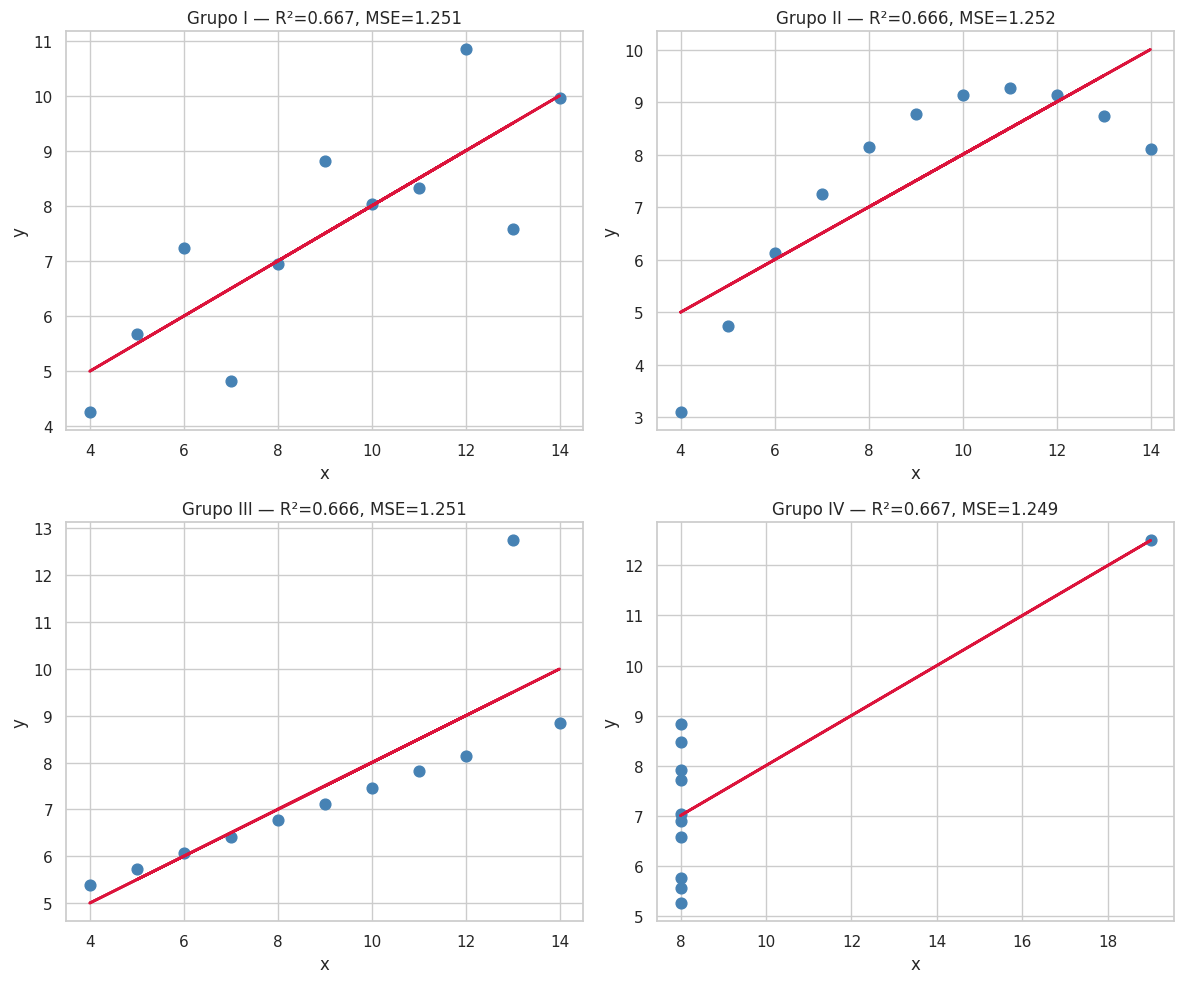

  dataset  pendiente  intercepto       mse        r2
0       I   0.500091    3.000091  1.251154  0.666542
1      II   0.500000    3.000909  1.252390  0.666242
2     III   0.499727    3.002455  1.250563  0.666324
3      IV   0.499909    3.001727  1.249317  0.666707


In [48]:
# Parte 3: Regresión lineal + MSE y R² para cada grupo
resultados_regresion = []

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, grupo in enumerate(['I', 'II', 'III', 'IV']):
    subset = data.loc[data['dataset'] == grupo]
    X = subset[['x']].values
    y = subset['y'].values

    modelo = LinearRegression()
    modelo.fit(X, y)
    y_pred = modelo.predict(X)

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    resultados_regresion.append({
        'dataset': grupo,
        'pendiente': modelo.coef_[0],
        'intercepto': modelo.intercept_,
        'mse': mse,
        'r2': r2
    })

    # Graficar puntos reales + recta ajustada
    axes[i].scatter(X, y, color='steelblue', s=60)
    axes[i].plot(X, y_pred, color='crimson', linewidth=2)
    axes[i].set_title(f'Grupo {grupo} — R²={r2:.3f}, MSE={mse:.3f}')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')

plt.tight_layout()
plt.show()

df_resultados = pd.DataFrame(resultados_regresion)
print(df_resultados)

Grupo II - Regresión polinomial (grado 2):
MSE: 0.0000 | R²: 1.0000


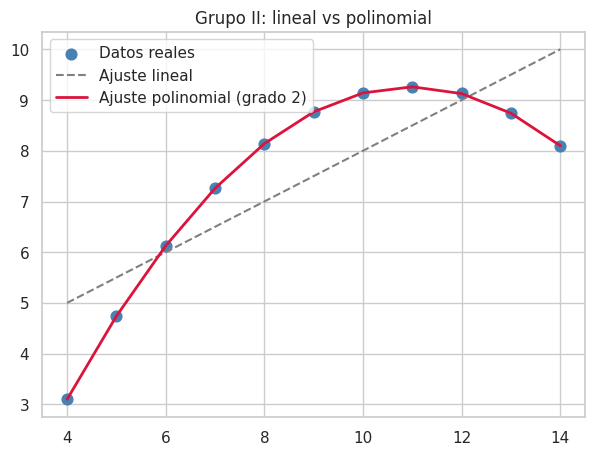

In [49]:
# Parte 4a: Grupo II - regresión polinomial (grado 2) en vez de lineal
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

subset_ii = data.loc[data['dataset'] == 'II']
X_ii = subset_ii[['x']].values
y_ii = subset_ii['y'].values

modelo_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
modelo_poly.fit(X_ii, y_ii)
y_pred_poly = modelo_poly.predict(X_ii)

mse_poly = mean_squared_error(y_ii, y_pred_poly)
r2_poly = r2_score(y_ii, y_pred_poly)

print(f"Grupo II - Regresión polinomial (grado 2):")
print(f"MSE: {mse_poly:.4f} | R²: {r2_poly:.4f}")

# Comparación visual: lineal vs polinomial
orden = np.argsort(X_ii.flatten())
plt.figure(figsize=(7, 5))
plt.scatter(X_ii, y_ii, color='steelblue', s=60, label='Datos reales')
plt.plot(X_ii[orden], LinearRegression().fit(X_ii, y_ii).predict(X_ii)[orden],
         color='gray', linestyle='--', label='Ajuste lineal')
plt.plot(X_ii[orden], y_pred_poly[orden], color='crimson', linewidth=2, label='Ajuste polinomial (grado 2)')
plt.title('Grupo II: lineal vs polinomial')
plt.legend()
plt.show()

Outlier detectado en x=13.0, y=12.74

Grupo III - Modelo SIN outlier:
MSE: 0.0000 | R²: 1.0000
(Comparar con el original: MSE=1.2506, R²=0.6663)


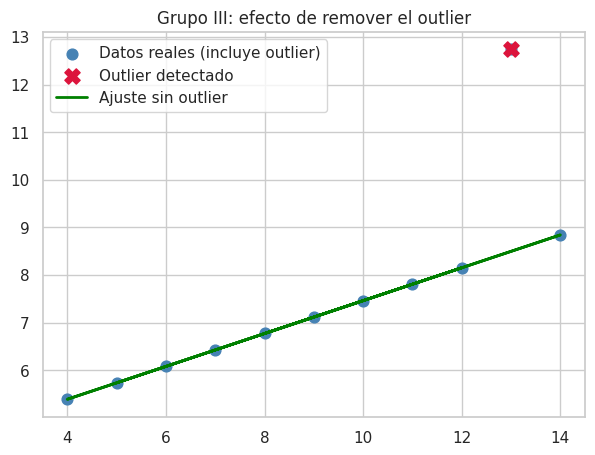

In [50]:
# Parte 4b: Grupo III - detectar y remover el outlier, reajustar modelo lineal
subset_iii = data.loc[data['dataset'] == 'III']
X_iii = subset_iii[['x']].values
y_iii = subset_iii['y'].values

# Ajuste original (con outlier)
modelo_original = LinearRegression().fit(X_iii, y_iii)
residuos = y_iii - modelo_original.predict(X_iii)

# Detectamos el outlier: el punto con el residuo absoluto más grande
idx_outlier = np.argmax(np.abs(residuos))
print(f"Outlier detectado en x={X_iii[idx_outlier][0]}, y={y_iii[idx_outlier]:.2f}")

# Reajustamos sin el outlier
X_iii_limpio = np.delete(X_iii, idx_outlier, axis=0)
y_iii_limpio = np.delete(y_iii, idx_outlier)

modelo_limpio = LinearRegression().fit(X_iii_limpio, y_iii_limpio)
y_pred_limpio = modelo_limpio.predict(X_iii_limpio)

mse_limpio = mean_squared_error(y_iii_limpio, y_pred_limpio)
r2_limpio = r2_score(y_iii_limpio, y_pred_limpio)

print(f"\nGrupo III - Modelo SIN outlier:")
print(f"MSE: {mse_limpio:.4f} | R²: {r2_limpio:.4f}")
print(f"(Comparar con el original: MSE=1.2506, R²=0.6663)")

# Comparación visual
plt.figure(figsize=(7, 5))
plt.scatter(X_iii, y_iii, color='steelblue', s=60, label='Datos reales (incluye outlier)')
plt.scatter(X_iii[idx_outlier], y_iii[idx_outlier], color='crimson', s=120, marker='X', label='Outlier detectado')
plt.plot(X_iii_limpio, y_pred_limpio, color='green', linewidth=2, label='Ajuste sin outlier')
plt.title('Grupo III: efecto de remover el outlier')
plt.legend()
plt.show()